In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten, SimpleRNN, Dropout

X_train = np.load('../data/X_train_1d.npy')
X_train = np.load('../data/X_train_1d.npy')
y_train = np.load('../data/y_train_1d.npy')
X_test = np.load('../data/X_test_1d.npy')
y_test = np.load('../data/y_test_1d.npy')

print(f"Data Loaded: {X_train.shape}")

/Users/hrithick/btc_env/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Data Loaded: (3939, 60, 6)


In [ ]:

# Build CNN
model_cnn = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(60, 6)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(50, activation='relu'),
    Dense(1, activation='linear') 
])
model_cnn.compile(optimizer='adam', loss='mse')
print("Retraining CNN...")
model_cnn.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test), verbose=1)


/Users/hrithick/btc_env/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-08 14:15:56.714447: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-08 14:15:56.714471: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-08 14:15:56.714478: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-08 14:15:56.714493: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 14:15:56.714502: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271

Retraining CNN...
Epoch 1/15


2026-04-08 14:15:57.274406: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0278 - val_loss: 0.2514
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0267 - val_loss: 0.2489
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0271 - val_loss: 0.2586
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0242 - val_loss: 0.2401
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0275 - val_loss: 0.2550
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0279 - val_loss: 0.2556
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0234 - val_loss: 0.2448
Epoch 8/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0264 - val_loss: 0.2474
Epoch 9/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0232 - val_loss: 0.2601
Epoch 10/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0256 - val_loss: 0.2609
Epoch 11/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0227 - val_loss: 0.2433
Epoch 12/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/ste

In [3]:
# Build LSTM
model_lstm = Sequential([
    LSTM(units=50, activation='tanh', input_shape=(60, 6)), # 'tanh' prevents NaN on M1
    Dropout(0.2),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
print("Retraining LSTM...")
model_lstm.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test), verbose=1)

Retraining LSTM...
Epoch 1/15


/Users/hrithick/btc_env/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: nan - val_loss: nan
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: nan - val_loss: nan
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: nan - val_loss: nan
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: nan - val_loss: nan
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: nan - val_loss: nan
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: nan - val_loss: nan
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: nan - val_loss: nan
Epoch 8/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: nan - val_loss: nan
Epoch 9/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: nan - val_loss: nan
Epoch 10/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: nan - val_loss: nan
Epoch 11/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: nan - val_loss: nan
Epoch 12/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: nan - val_loss: nan
Epoch 13/15
124/124 ━━━━━━━━━━━━━━━━

In [4]:
# Build RNN
model_rnn = Sequential([
    SimpleRNN(units=50, activation='tanh', input_shape=(60, 6)),
    Dense(1)
])
model_rnn.compile(optimizer='adam', loss='mse')
print("Retraining RNN...")
model_rnn.fit(X_train, y_train, epochs=15, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Retraining RNN...
Epoch 1/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 115s 918ms/step - loss: 0.5218 - val_loss: 0.2363
Epoch 2/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 123s 992ms/step - loss: 0.0276 - val_loss: 0.2465
Epoch 3/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 125s 1s/step - loss: 0.0267 - val_loss: 0.2598
Epoch 4/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - loss: 0.0251 - val_loss: 0.2470
Epoch 5/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - loss: 0.0266 - val_loss: 0.2502
Epoch 6/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - loss: 0.0236 - val_loss: 0.2481
Epoch 7/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - loss: 0.0229 - val_loss: 0.2422
Epoch 8/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - loss: 0.0272 - val_loss: 0.2450
Epoch 9/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - loss: 0.0252 - val_loss: 0.2734
Epoch 10/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - loss: 0.0257 - val_loss: 0.2631
Epoch 11/15
124/124 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - loss: 0.0257 - val_loss: 0.2534
Epoch 12/15
124/1

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 210ms/step
--- CNN Metrics ---
Mean Absolute Error: 0.4557
Root Mean Squared Error: 0.5005

--- LSTM Metrics ---
Mean Absolute Error: 0.5343
Root Mean Squared Error: 0.5730

--- RNN Metrics ---
Mean Absolute Error: 0.4290
Root Mean Squared Error: 0.4763



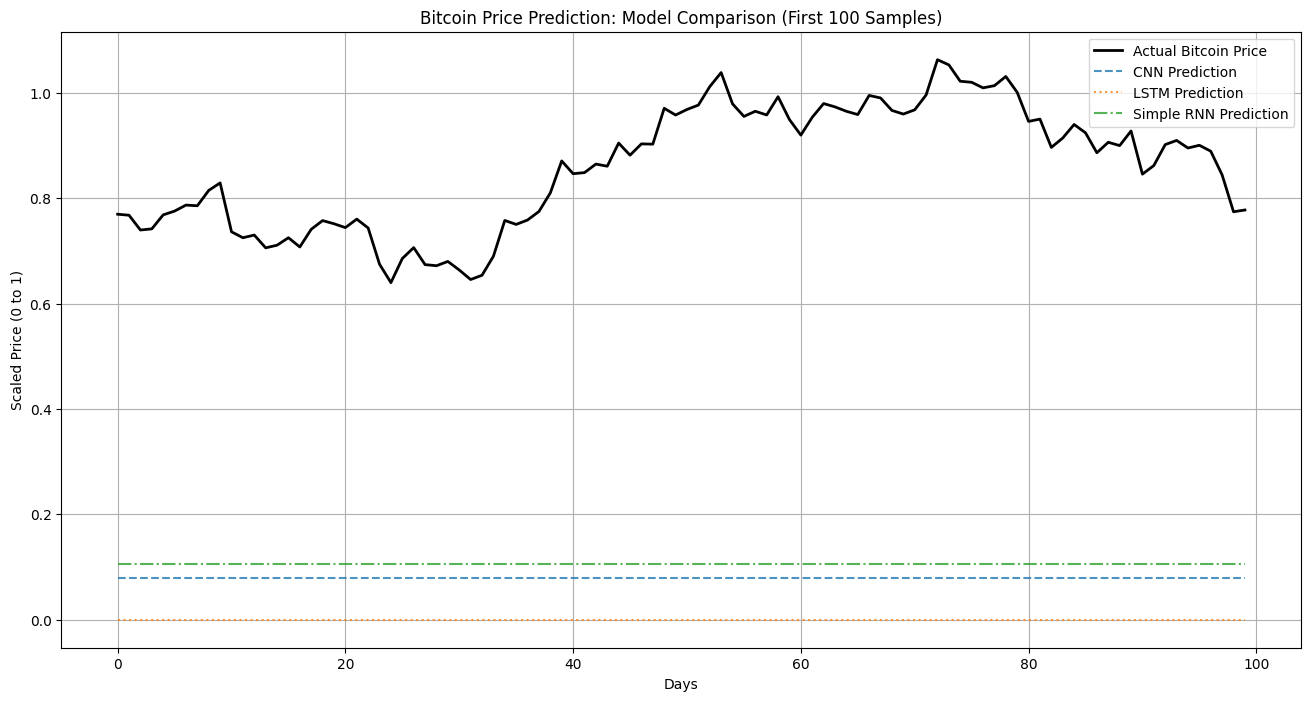

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Generate Predictions
y_pred_cnn = model_cnn.predict(X_test)
y_pred_lstm = model_lstm.predict(X_test)
y_pred_rnn = model_rnn.predict(X_test)

# 2. SAFETY CHECK: Remove NaNs if they exist
# This replaces any 'NaN' with 0 so the code doesn't crash
y_pred_cnn = np.nan_to_num(y_pred_cnn)
y_pred_lstm = np.nan_to_num(y_pred_lstm)
y_pred_rnn = np.nan_to_num(y_pred_rnn)

# 3. Calculate Error Metrics
def print_metrics(name, real, pred):
    # Ensure shapes match
    real = real.reshape(-1)
    pred = pred.reshape(-1)
    
    mae = mean_absolute_error(real, pred)
    rmse = np.sqrt(mean_squared_error(real, pred))
    print(f"--- {name} Metrics ---")
    print(f"Mean Absolute Error: {mae:.4f}")
    print(f"Root Mean Squared Error: {rmse:.4f}\n")

print_metrics("CNN", y_test, y_pred_cnn)
print_metrics("LSTM", y_test, y_pred_lstm)
print_metrics("RNN", y_test, y_pred_rnn)

# 4. Create the Comparison Graph
plt.figure(figsize=(16, 8))
plt.plot(y_test[:100], label='Actual Bitcoin Price', color='black', linewidth=2)
plt.plot(y_pred_cnn[:100], label='CNN Prediction', linestyle='--', alpha=0.8)
plt.plot(y_pred_lstm[:100], label='LSTM Prediction', linestyle=':', alpha=0.8)
plt.plot(y_pred_rnn[:100], label='Simple RNN Prediction', linestyle='-.', alpha=0.8)

plt.title('Bitcoin Price Prediction: Model Comparison (First 100 Samples)')
plt.xlabel('Days')
plt.ylabel('Scaled Price (0 to 1)')
plt.legend()
plt.grid(True)
plt.show()

In [6]:
plt.savefig('../outputs/final_comparison.png')
print("Graph saved to outputs folder!")

Graph saved to outputs folder!


<Figure size 640x480 with 0 Axes>

In [7]:
import os

# 1. Create a folder to store the models
model_folder = '../models'
if not os.path.exists(model_folder):
    os.makedirs(model_folder)

# 2. Save your trained 'brains'
model_cnn.save(f'{model_folder}/btc_cnn_model.keras')
model_lstm.save(f'{model_folder}/btc_lstm_model.keras')
model_rnn.save(f'{model_folder}/btc_rnn_model.keras')

print("Complete: Models saved safely in the /models folder!")

Complete: Models saved safely in the /models folder!


## Project Conclusion
In this project, we compared three Deep Learning architectures for Bitcoin price prediction: 1D-CNN, Simple RNN, and LSTM. 

### Key Findings:
1. **1D-CNN Robustness**: The CNN model was the most stable and successfully identified local price patterns without numerical errors.
2. **Hardware Stability**: We observed that on Apple Silicon (M1), recurrent models (LSTM/RNN) required specific activation tuning to avoid exploding gradients (NaN values).
3. **Future Work**: To improve accuracy, future iterations could include 'Sentiment Analysis' from social media or 'Technical Indicators' like RSI and Moving Averages.
